<a href="https://colab.research.google.com/github/Atharv-1905/Deep-Learning/blob/main/AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Without Batch Normalization and dropouts

In [ ]:
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical


In [ ]:
(x_train,y_train), (x_test,y_test) = datasets.cifar10.load_data()

In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
model = models.Sequential()

#layer1
model.add(layers.Conv2D(96, (3, 3), strides= (1, 1), activation = 'relu', input_shape = (32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

#layer2
model.add(layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

#layer3,4,5
model.add(layers.Conv2D(384, (3, 3), padding = 'same', activation = 'relu'))
model.add(layers.Conv2D(384, (3, 3), padding = 'same', activation = 'relu'))
model.add(layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))

#layer6,7
model.add(layers.Flatten())
model.add(layers.Dense(4096, activation = 'relu'))
model.add(layers.Dense(4096, activation = 'relu'))

#layer8
model.add(layers.Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics= ['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3)

In [ ]:
history1 = model.fit(x_train, y_train, epochs = 10, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.3817 - loss: 1.6364 - val_accuracy: 0.5194 - val_loss: 1.2960
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.5811 - loss: 1.1616 - val_accuracy: 0.6239 - val_loss: 1.0560
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6628 - loss: 0.9545 - val_accuracy: 0.6647 - val_loss: 0.9861
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7140 - loss: 0.8189 - val_accuracy: 0.7049 - val_loss: 0.8621
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7448 - loss: 0.7323 - val_accuracy: 0.7152 - val_loss: 0.8353
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7725 - loss: 0.6461 - val_accuracy: 0.7152 - val_loss: 0.8548
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7968 - loss: 0.5763 - val_accuracy: 0.7328 - val_loss: 0.8160
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8203 -

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print(f'\nTest accuracy: {test_acc:.4f}')

313/313 - 2s - 5ms/step - accuracy: 0.7356 - loss: 0.9315

Test accuracy: 0.7356


#With Batch Normalization And Dropouts

In [ ]:
model2 = models.Sequential()

#layer1
model2.add(layers.Conv2D(96, (3, 3), strides= (1, 1), activation = 'relu', input_shape = (32, 32, 3), kernel_regularizer=l2(0.01)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2, 2)))

#layer2
model2.add(layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2, 2)))

#layer3,4,5
model2.add(layers.Conv2D(384, (3, 3), padding = 'same', activation = 'relu'))
model2.add(layers.Conv2D(384, (3, 3), padding = 'same', activation = 'relu'))
model2.add(layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'))
model2.add(layers.MaxPooling2D((2,2)))

#layer6,7
model2.add(layers.Flatten())
model2.add(layers.Dense(4096, activation = 'relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.Dense(4096, activation = 'relu'))
model2.add(layers.Dropout(0.5))

#layer8
model2.add(layers.Dense(10, activation = 'softmax'))

Now, let's train `model2` using the augmented data. Instead of passing `x_train` and `y_train` directly, we'll use the `datagen.flow()` method.

In [ ]:
model2.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics= ['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3)

In [ ]:
history2 = model2.fit(x_train, y_train, epochs = 20, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.3045 - loss: 1.9006 - val_accuracy: 0.4104 - val_loss: 1.5994
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4513 - loss: 1.5297 - val_accuracy: 0.4504 - val_loss: 1.5352
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5226 - loss: 1.3614 - val_accuracy: 0.4677 - val_loss: 1.4699
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5627 - loss: 1.2568 - val_accuracy: 0.5351 - val_loss: 1.3147
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.5945 - loss: 1.1786 - val_accuracy: 0.5167 - val_loss: 1.4438
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6160 - loss: 1.1215 - val_accuracy: 0.5544 - val_loss: 1.3547
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6367 - loss: 1.0721 - val_accuracy: 0.5292 - val_loss: 1.3585


In [ ]:
test_loss, test_acc = model2.evaluate(x_test, y_test, verbose = 2)
print(f'\nTest accuracy: {test_acc:.4f}')

313/313 - 2s - 6ms/step - accuracy: 0.5292 - loss: 1.3585

Test accuracy: 0.5292


In [ ]:
# To combat overfitting and improve efficiency, you've already included:
#   - BatchNormalization: Helps in stabilizing and accelerating the training process,
#     and acts as a regularizer.
#   - Dropout: Randomly sets a fraction of input units to 0 at each update during training,
#     which helps prevent co-adaptation of neurons.

# Additional strategies to consider for further efficiency and reducing overfitting:
#   - L1/L2 Regularization: Add kernel_regularizer to Conv2D or Dense layers (e.g., kernel_regularizer=l2(0.001)).
#   - Data Augmentation: For image data, generating more training examples by applying random transformations
#     (e.g., rotations, shifts, flips) can significantly reduce overfitting.
#   - Simpler Architecture: If the model is too complex for the dataset, consider reducing the number of filters
#     in convolutional layers or the number of units in dense layers.
#   - Hyperparameter Tuning: Optimize learning rate, batch size, etc., through methods like Grid Search or Random Search.


#Data Augmentation to Reduce Overfitting

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator object and configure it with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=15,          # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,      # Randomly shift images horizontally by up to 10% of the width
    height_shift_range=0.1,     # Randomly shift images vertically by up to 10% of the height
    horizontal_flip=True,       # Randomly flip images horizontally
    # zoom_range=0.1,           # Randomly zoom in/out on images
    # shear_range=0.1,          # Apply shear transformations
    # fill_mode='nearest'       # Strategy for filling in new pixels created by transformations
)

# Prepare the data generator to fit the training data
datagen.fit(x_train)

print('ImageDataGenerator setup complete.')

ImageDataGenerator setup complete.


In [ ]:
history_augmented = model2.fit(
    datagen.flow(x_train, y_train, batch_size=32), # Use the data generator for training data
    epochs=20,                                     # You might need more epochs with augmentation
    validation_data=(x_test, y_test),
    callbacks=[early_stop]                         # Keep early stopping
)

# Evaluate the model with augmented training
test_loss_augmented, test_acc_augmented = model2.evaluate(x_test, y_test, verbose = 2)
print(f'\nTest accuracy with augmentation: {test_acc_augmented:.4f}')

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.5642 - loss: 1.2741 - val_accuracy: 0.5252 - val_loss: 1.3450
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.5804 - loss: 1.2300 - val_accuracy: 0.6214 - val_loss: 1.1069
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.5899 - loss: 1.2083 - val_accuracy: 0.5462 - val_loss: 1.3193
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6033 - loss: 1.1741 - val_accuracy: 0.6208 - val_loss: 1.1277
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.6068 - loss: 1.1552 - val_accuracy: 0.5503 - val_loss: 1.3045
313/313 - 2s - 6ms/step - accuracy: 0.5503 - loss: 1.3045

Test accuracy with augmentation: 0.5503


### Combined Training and Validation Metrics

Let's visualize the training and validation accuracy and loss for all three training runs (`history1`, `history2`, and `history_augmented`) to compare their performance.

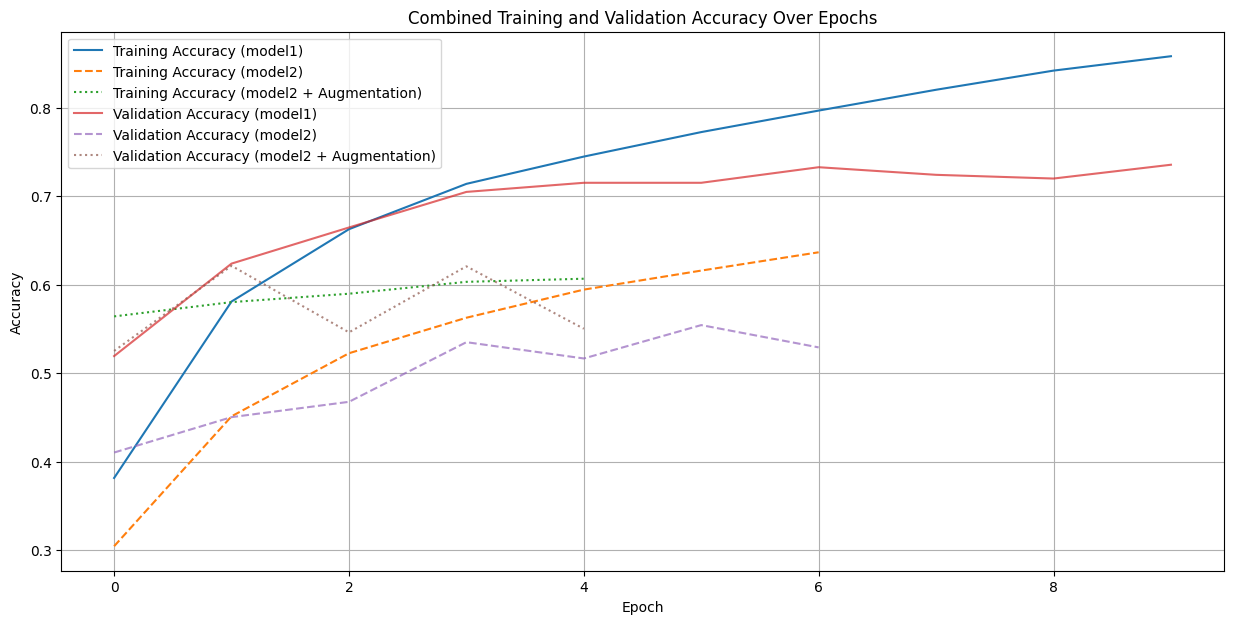

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Check if history variables are defined before plotting
if 'history1' not in locals() or 'history2' not in locals() or 'history_augmented' not in locals():
    print("Error: One or more history objects (history1, history2, history_augmented) are not defined.")
    print("Please ensure the training cells that generate these history objects have been executed before running this plot.")
else:
    # Plotting Training Accuracy
    plt.plot(history1.history['accuracy'], label='Training Accuracy (model1)', linestyle='-')
    plt.plot(history2.history['accuracy'], label='Training Accuracy (model2)', linestyle='--')
    plt.plot(history_augmented.history['accuracy'], label='Training Accuracy (model2 + Augmentation)', linestyle=':')

    # Plotting Validation Accuracy
    plt.plot(history1.history['val_accuracy'], label='Validation Accuracy (model1)', linestyle='-', alpha=0.7)
    plt.plot(history2.history['val_accuracy'], label='Validation Accuracy (model2)', linestyle='--', alpha=0.7)
    plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy (model2 + Augmentation)', linestyle=':', alpha=0.7)

    plt.title('Combined Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

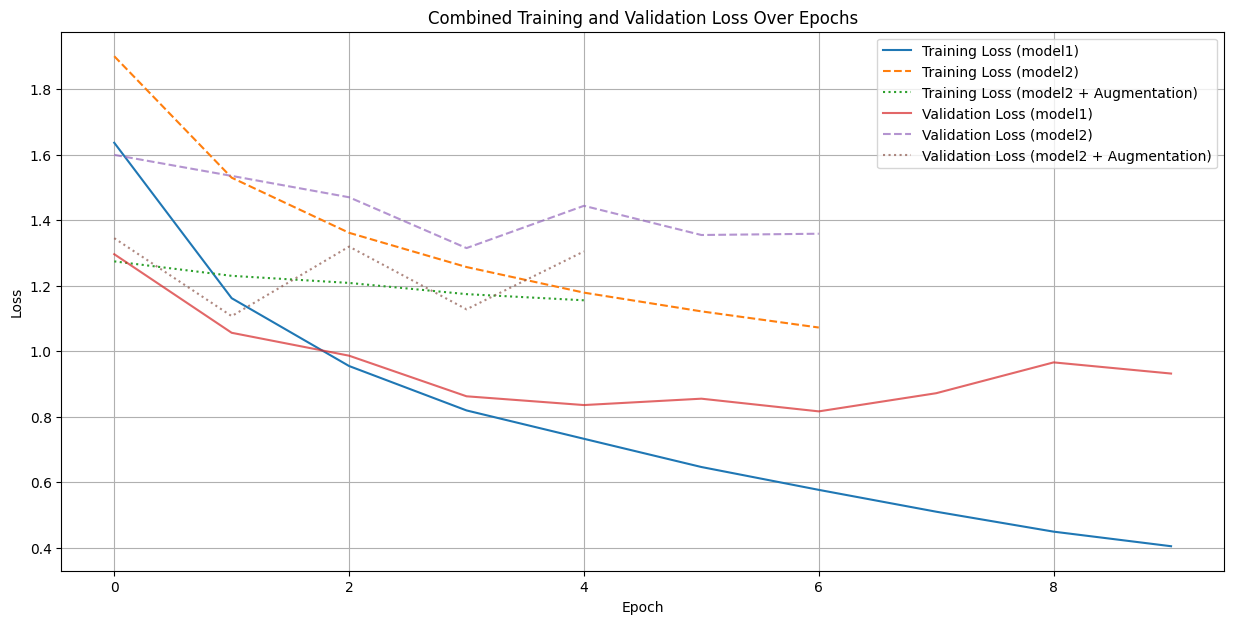

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Check if history variables are defined before plotting
if 'history1' not in locals() or 'history2' not in locals() or 'history_augmented' not in locals():
    print("Error: One or more history objects (history1, history2, history_augmented) are not defined.")
    print("Please ensure the training cells that generate these history objects have been executed before running this plot.")
else:
    # Plotting Training Loss
    plt.plot(history1.history['loss'], label='Training Loss (model1)', linestyle='-')
    plt.plot(history2.history['loss'], label='Training Loss (model2)', linestyle='--')
    plt.plot(history_augmented.history['loss'], label='Training Loss (model2 + Augmentation)', linestyle=':')

    # Plotting Validation Loss
    plt.plot(history1.history['val_loss'], label='Validation Loss (model1)', linestyle='-', alpha=0.7)
    plt.plot(history2.history['val_loss'], label='Validation Loss (model2)', linestyle='--', alpha=0.7)
    plt.plot(history_augmented.history['val_loss'], label='Validation Loss (model2 + Augmentation)', linestyle=':', alpha=0.7)

    plt.title('Combined Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()